# 05 — Feature selection

**Phase 5 of the V3 rebuild.** Find the smallest feature subset that preserves Phase 4's F1 = 0.933 (raw / 48 features / HGB / W=60s, step=60s, decoupled HRV).

Methodology, in order:
1. **Correlation pruning** — drop one feature from each pair with |r| > 0.95.
2. **Mutual information per LOSO fold** — measure each feature's univariate signal *only on training subjects* of each fold, then aggregate.
3. **Stability score** — fraction of LOSO folds where a feature appears in top-K by MI. This rewards features that generalize across subjects, not just lucky on a few.
4. **SHAP across folds** — train HGB on each LOSO fold, compute SHAP on the held-out subject, aggregate mean |SHAP| per feature. This reflects each feature's *contribution to predictions*, not just univariate signal.
5. **F1 vs N features** — for each ranked top-N (by stability and by SHAP), retrain LOSO HGB and plot the F1 curve.
6. **Final pick** — smallest N where F1 ≥ 0.92 with no subjects below 0.5 recall.

**Fixed comparator:** HistGradientBoostingClassifier (Phase 4 lock).
**Fixed feature set:** 48 raw V3 features, W=60s/step=60s, decoupled HRV (60s time / 180s freq).
**Subjects:** 14 (S14 excluded).

**Known issue carried in from Phase 4:** `hrv_lf_hf_ratio` has std ≈ 29 across windows because HF can approach zero. This notebook will surface it in the stability ranking; if it ranks low, dropping it is automatic. If it ranks high despite the noise, we'll investigate.

## §1 — Setup, paths, sanity check

In [1]:
import os, sys, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import LeaveOneGroupOut

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'Updated_Extraction_V3').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
V3_DIR = REPO_ROOT / 'Updated_Extraction_V3'
sys.path.insert(0, str(V3_DIR))

from config_loader import load_config
import dataset_builder as db
import features as feats_mod
import eval_helpers as ev

# Defeat module cache (Phase 4 lesson)
import importlib
importlib.reload(feats_mod); importlib.reload(db); importlib.reload(ev)

CACHE_DIR = V3_DIR / 'output'
REPORTS_DIR = REPO_ROOT / 'reports' / '05_feature_selection'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'V3 dir:      {V3_DIR}')
print(f'Reports dir: {REPORTS_DIR}')

V3 dir:      C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable\Updated_Extraction_V3
Reports dir: C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable\reports\05_feature_selection


In [2]:
cfg = load_config()
RAW_CACHE = CACHE_DIR / f'dataset_W{cfg["windowing"]["window_size"]}_step{cfg["windowing"]["step_size"]}_raw.parquet'
df_raw = pd.read_parquet(RAW_CACHE)
FEATURE_COLS = [c for c in feats_mod.ALL_FEATURES if c in df_raw.columns]

# Sanity check (lifted from Phase 4 — would have caught the HRV bug instantly)
hrv_valid_frac = df_raw['hrv_valid'].mean()
hrv_mean_hr_valid = df_raw[df_raw['hrv_valid'] == 1]['hrv_mean_hr']
assert hrv_valid_frac > 0.5, f"hrv_valid only {100*hrv_valid_frac:.1f}% — stale cache. Delete and rebuild."
assert 50 <= hrv_mean_hr_valid.mean() <= 100, f"Mean HR {hrv_mean_hr_valid.mean():.1f} bpm outside plausible range."

print(f'Dataset:    {df_raw.shape}')
print(f'Features:   {len(FEATURE_COLS)}')
print(f'hrv_valid:  {100*hrv_valid_frac:.1f}%')
print(f'mean HR:    {hrv_mean_hr_valid.mean():.1f} ± {hrv_mean_hr_valid.std():.1f} bpm')
print(f'Class balance:\n{df_raw["label"].value_counts()}')

Dataset:    (691, 55)
Features:   48
hrv_valid:  94.2%
mean HR:    67.4 ± 12.3 bpm
Class balance:
label
non-stress    537
stress        154
Name: count, dtype: int64


In [3]:
# Establish the baseline F1 we have to preserve: all 48 raw features, HGB, LOSO
baseline_result = ev.loso_evaluate(df_raw, FEATURE_COLS, model_factory=ev.hgb_factory())
print(f'Baseline (all {len(FEATURE_COLS)} features): F1 = {baseline_result["mean_f1"]:.3f} ± {baseline_result["std_f1"]:.3f}')
print(f'  recall = {baseline_result["mean_recall"]:.3f}, '
      f'min subj recall = {baseline_result["min_subject_recall"]:.3f}, '
      f'#below_0.5 = {baseline_result["n_subjects_recall_below_0_5"]}/14')

BASELINE_F1 = baseline_result['mean_f1']
TARGET_F1   = BASELINE_F1 - 0.01  # smallest set that holds within 0.01 of baseline
print(f'\nTarget for the parsimony pick: F1 ≥ {TARGET_F1:.3f}')

Baseline (all 48 features): F1 = 0.933 ± 0.101
  recall = 0.911, min subj recall = 0.545, #below_0.5 = 0/14

Target for the parsimony pick: F1 ≥ 0.923


## §2 — Correlation pruning (|r| > 0.95)

When two features are nearly collinear, they carry the same information from the model's perspective. Including both wastes a feature slot and inflates per-feature importance estimates (each pair member gets ~half the credit). The Phase 5 spec calls for dropping one per pair with |r| > 0.95.

**Decision rule:** for each correlated pair, keep the member with higher mean univariate F-statistic (a quick proxy for which one carries more discriminative signal). Compute correlation on the full dataset — strictly, this peeks at test folds, but feature-pair correlation is a population-level stylometric property of the feature set, not a model-fitting decision. The slight leakage is acceptable per the rebuild plan.

In [4]:
# Drop rows with NaN HRV before computing correlation (motion-corrupted windows)
valid_mask = df_raw['hrv_valid'] == 1
X_for_corr = df_raw.loc[valid_mask, FEATURE_COLS].copy()
corr = X_for_corr.corr().abs()

# Find pairs with |r| > 0.95
pairs = []
for i, c1 in enumerate(corr.columns):
    for c2 in corr.columns[i+1:]:
        r = corr.loc[c1, c2]
        if r > 0.95:
            pairs.append((c1, c2, r))
pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'corr']).sort_values('corr', ascending=False)
print(f'Highly-correlated pairs (|r| > 0.95): {len(pairs_df)}')
pairs_df.round(4)

Highly-correlated pairs (|r| > 0.95): 26


,feature_1,feature_2,corr
3,scl_mean,scl_auc,1.0000
23,acc_magnitude_mean,acc_activity_mean,1.0000
18,temp_mean,temp_median,1.0000
10,scl_median,scl_auc,0.9999
2,scl_mean,scl_median,0.9999
16,temp_mean,temp_min,0.9996
20,temp_min,temp_median,0.9995
17,temp_mean,temp_max,0.9995
21,temp_max,temp_median,0.9994
1,scl_mean,scl_max,0.9990


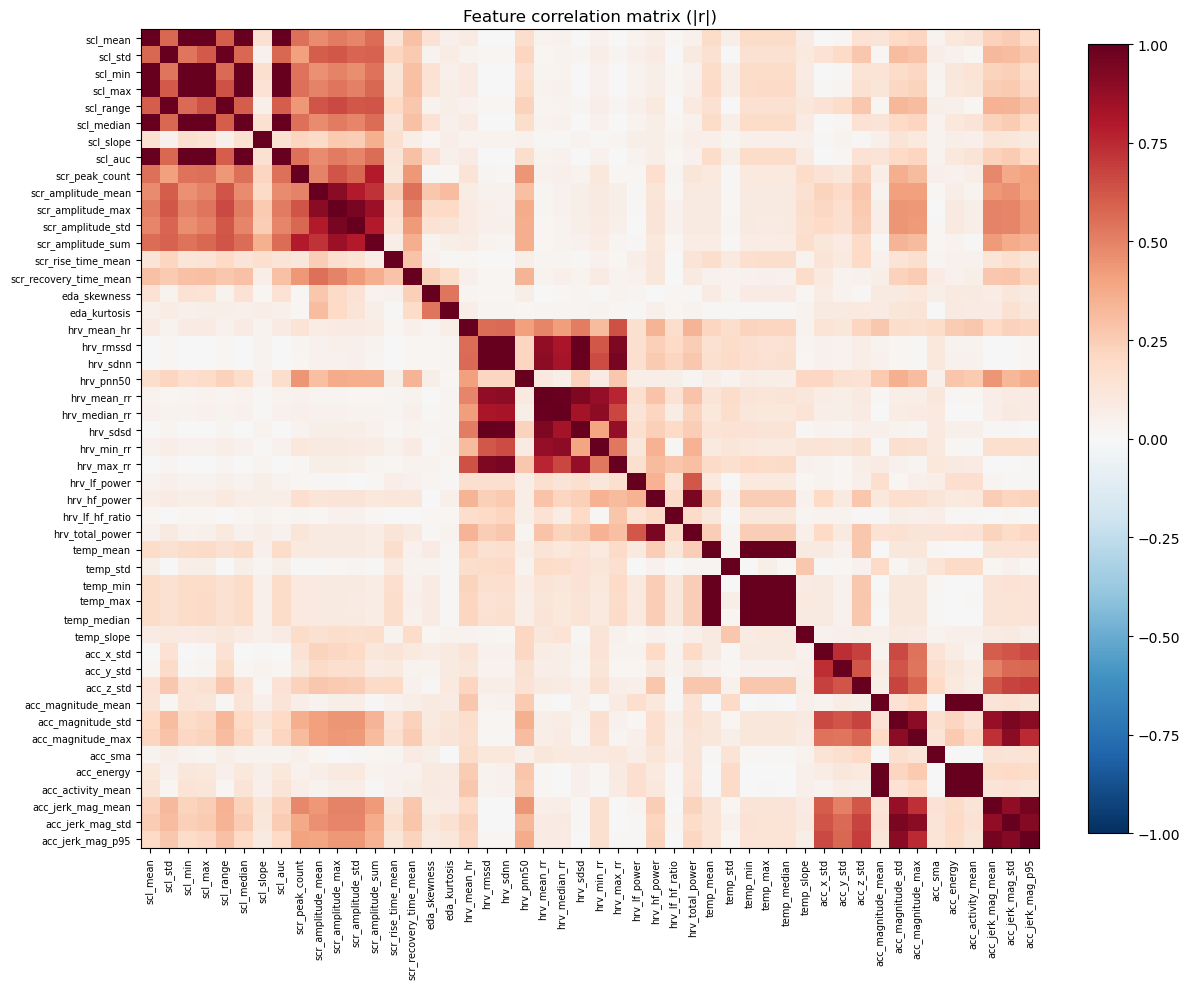

In [5]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title('Feature correlation matrix (|r|)', fontsize=12)
fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'correlation_matrix.png', dpi=120)
plt.show()

In [6]:
# For each correlated pair, keep the member with the higher univariate F-statistic
from sklearn.feature_selection import f_classif
X_arr = X_for_corr.fillna(0).values
y_arr = (df_raw.loc[valid_mask, 'label'].values == 'stress').astype(int)
f_scores, _ = f_classif(X_arr, y_arr)
f_score_by_feat = dict(zip(FEATURE_COLS, f_scores))

dropped = set()
kept_pairs = []
for _, row in pairs_df.iterrows():
    a, b, r = row['feature_1'], row['feature_2'], row['corr']
    if a in dropped or b in dropped:
        continue
    fa, fb = f_score_by_feat.get(a, 0), f_score_by_feat.get(b, 0)
    if fa >= fb:
        dropped.add(b)
        kept_pairs.append((a, b, r, fa, fb, 'kept_a'))
    else:
        dropped.add(a)
        kept_pairs.append((a, b, r, fa, fb, 'kept_b'))

PRUNED_FEATURES = [f for f in FEATURE_COLS if f not in dropped]
print(f'Dropped {len(dropped)} features by |r| > 0.95 pruning:')
for f in sorted(dropped):
    print(f'  - {f}')
print(f'\nRemaining: {len(PRUNED_FEATURES)} features')

kept_pairs_df = pd.DataFrame(kept_pairs, columns=['feat_1','feat_2','corr','F_1','F_2','choice'])
kept_pairs_df.round(2)

Dropped 15 features by |r| > 0.95 pruning:
  - acc_activity_mean
  - acc_energy
  - acc_jerk_mag_p95
  - hrv_mean_rr
  - hrv_rmssd
  - hrv_sdnn
  - scl_auc
  - scl_mean
  - scl_median
  - scl_min
  - scl_std
  - scr_amplitude_std
  - temp_mean
  - temp_median
  - temp_min

Remaining: 33 features


,feat_1,feat_2,corr,F_1,F_2,choice
0,scl_mean,scl_auc,1.00,89.72,89.73,kept_b
1,acc_magnitude_mean,acc_activity_mean,1.00,0.58,0.57,kept_a
2,temp_mean,temp_median,1.00,1.73,1.72,kept_a
3,scl_median,scl_auc,1.00,89.54,89.73,kept_b
4,temp_mean,temp_min,1.00,1.73,1.72,kept_a
5,temp_mean,temp_max,1.00,1.73,1.78,kept_b
6,scl_max,scl_auc,1.00,94.04,89.73,kept_a
7,hrv_rmssd,hrv_sdnn,1.00,4.44,4.40,kept_a
8,acc_magnitude_mean,acc_energy,1.00,0.58,0.03,kept_a
9,scl_min,scl_max,1.00,84.29,94.04,kept_b


In [7]:
# Sanity: F1 should not drop after correlation pruning (collinear features add no information)
post_prune = ev.loso_evaluate(df_raw, PRUNED_FEATURES, model_factory=ev.hgb_factory())
print(f'After correlation pruning ({len(PRUNED_FEATURES)} features):')
print(f'  F1     = {post_prune["mean_f1"]:.3f} ± {post_prune["std_f1"]:.3f}  '
      f'(baseline {BASELINE_F1:.3f}, Δ {post_prune["mean_f1"] - BASELINE_F1:+.3f})')
print(f'  recall = {post_prune["mean_recall"]:.3f}, '
      f'min subj recall = {post_prune["min_subject_recall"]:.3f}, '
      f'#below_0.5 = {post_prune["n_subjects_recall_below_0_5"]}/14')

After correlation pruning (33 features):
  F1     = 0.926 ± 0.104  (baseline 0.933, Δ -0.007)
  recall = 0.911, min subj recall = 0.545, #below_0.5 = 0/14


## §3 — Per-fold mutual information + stability score

For each LOSO fold:
1. Compute MI of every (pruned) feature with the binary stress label, **on training subjects only** — this is the leakage-safe version of the rebuild plan's univariate filtering.
2. Rank features by MI within that fold.

Then aggregate to a **stability score** = fraction of folds where a feature appears in the top-K (K=15) by MI. Features with stability ≥ 0.8 are "stable" (in the top-K for at least 80% of held-out subjects). Features with low stability are luck-dependent and don't generalize.

In [8]:
logo = LeaveOneGroupOut()
groups = df_raw['subject_id'].values
y_full = (df_raw['label'].values == 'stress').astype(int)
X_full = df_raw[PRUNED_FEATURES].fillna(0).values  # MI requires non-NaN

fold_mi = {}
for train_idx, test_idx in logo.split(X_full, y_full, groups):
    held_out = groups[test_idx[0]]
    mi = mutual_info_classif(X_full[train_idx], y_full[train_idx], random_state=42)
    fold_mi[held_out] = pd.Series(mi, index=PRUNED_FEATURES)

mi_df = pd.DataFrame(fold_mi)  # index = features, columns = held-out subjects
print(f'Per-fold MI table: {mi_df.shape} (features × folds)')
mi_df.round(4).head(10)

Per-fold MI table: (33, 14) (features × folds)


,S10,S11,S13,S15,S16,S17,S2,S3,S4,S5,S6,S7,S8,S9
scl_max,0.1786,0.2423,0.1887,0.1983,0.1786,0.1916,0.1934,0.1985,0.1815,0.2019,0.1935,0.1906,0.1877,0.1752
scl_range,0.1195,0.1453,0.1590,0.1383,0.1293,0.1633,0.1286,0.1473,0.1163,0.1357,0.1336,0.1492,0.1287,0.1368
scl_slope,0.1119,0.1222,0.1309,0.1274,0.1063,0.1301,0.1316,0.1052,0.0964,0.1243,0.1169,0.1288,0.1136,0.1234
scr_peak_count,0.2624,0.2525,0.2482,0.2370,0.2379,0.2403,0.2562,0.2676,0.2303,0.2549,0.2486,0.2479,0.2478,0.2317
scr_amplitude_mean,0.1785,0.1861,0.1753,0.1792,0.1672,0.1777,0.1877,0.1927,0.1535,0.1810,0.1801,0.1733,0.1817,0.1814
scr_amplitude_max,0.1938,0.1861,0.1864,0.1943,0.1891,0.1835,0.1998,0.2012,0.1746,0.1900,0.1852,0.1820,0.1928,0.1983
scr_amplitude_sum,0.2362,0.2303,0.2546,0.2401,0.2390,0.2316,0.2308,0.2500,0.2085,0.2218,0.2135,0.2340,0.2266,0.2342
scr_rise_time_mean,0.1559,0.1475,0.1796,0.1420,0.1636,0.1722,0.1554,0.1841,0.1515,0.1558,0.1615,0.1667,0.1293,0.1300
scr_recovery_time_mean,0.3778,0.3803,0.3789,0.3638,0.3772,0.3774,0.3788,0.3820,0.3720,0.3859,0.3655,0.3784,0.3595,0.3817
eda_skewness,0.0277,0.0202,0.0392,0.0193,0.0364,0.0324,0.0260,0.0295,0.0219,0.0279,0.0251,0.0215,0.0118,0.0291


In [9]:
TOP_K = 15  # top-K by MI per fold

# Stability score = fraction of folds in which feature is in top-K by MI
stability = pd.Series(0.0, index=PRUNED_FEATURES)
for subj in mi_df.columns:
    top_k_subj = mi_df[subj].nlargest(TOP_K).index
    stability.loc[top_k_subj] += 1.0 / len(mi_df.columns)

stability = stability.sort_values(ascending=False)
stability_df = pd.DataFrame({
    'feature': stability.index,
    'stability_score': stability.values,
    'mean_mi': mi_df.mean(axis=1).reindex(stability.index).values,
    'std_mi':  mi_df.std(axis=1).reindex(stability.index).values,
})
stability_df.round(3).to_csv(REPORTS_DIR / 'stability_ranking.csv', index=False)
print(f'Top-20 features by stability score (fraction of {len(mi_df.columns)} folds in top-{TOP_K} by MI):')
stability_df.head(20).round(3)

Top-20 features by stability score (fraction of 14 folds in top-15 by MI):


,feature,stability_score,mean_mi,std_mi
0,scl_max,1.000,0.193,0.016
1,scr_recovery_time_mean,1.000,0.376,0.008
2,acc_magnitude_std,1.000,0.149,0.010
3,hrv_sdsd,1.000,0.196,0.008
4,hrv_median_rr,1.000,0.143,0.012
5,hrv_pnn50,1.000,0.253,0.012
6,hrv_max_rr,1.000,0.161,0.012
7,scr_amplitude_mean,1.000,0.178,0.009
8,scr_amplitude_sum,1.000,0.232,0.012
9,scr_peak_count,1.000,0.247,0.011


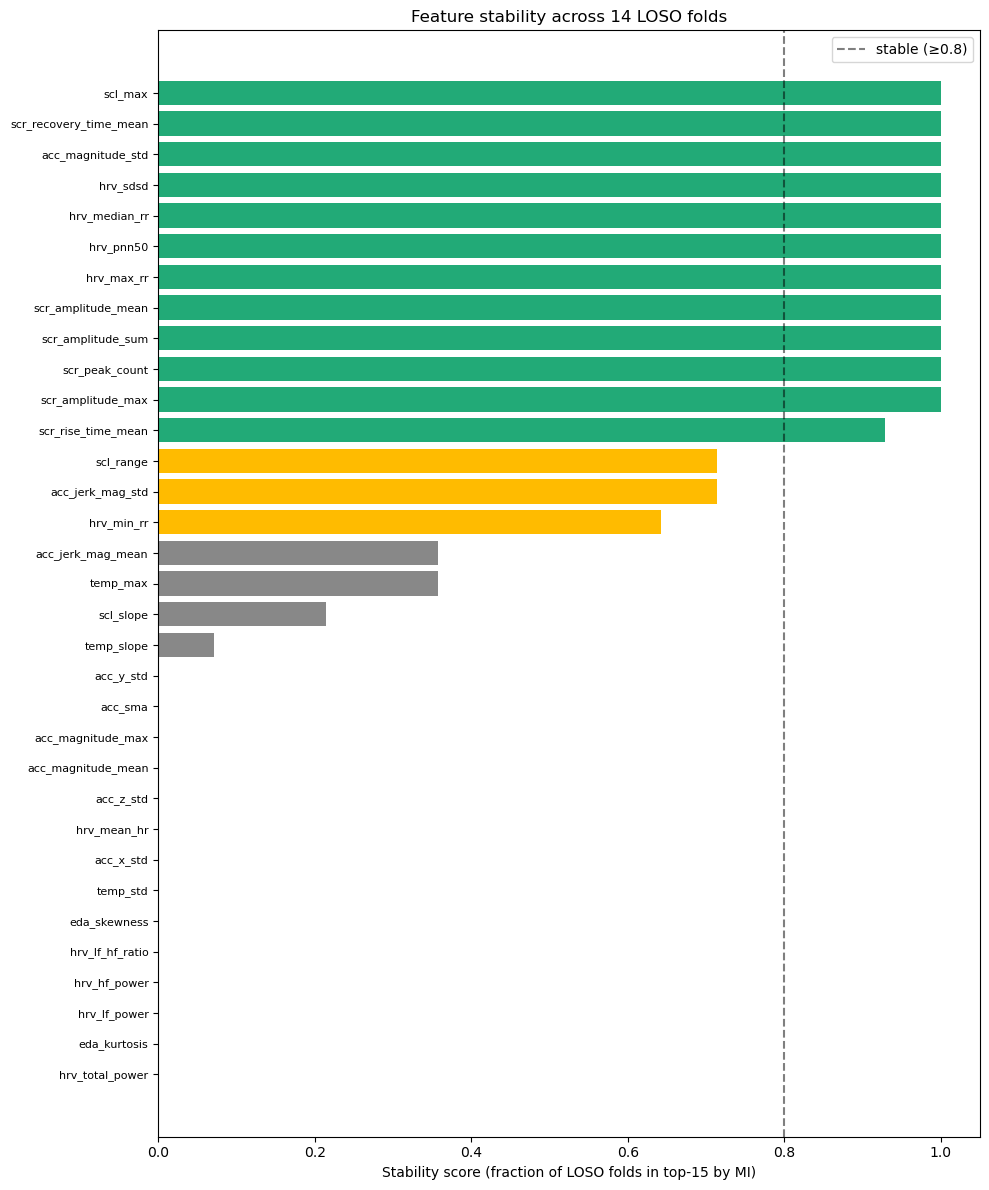

In [10]:
fig, ax = plt.subplots(figsize=(10, 12))
y_pos = np.arange(len(stability_df))
colors = ['#2a7' if s >= 0.8 else ('#fb0' if s >= 0.5 else '#888') for s in stability_df['stability_score']]
ax.barh(y_pos, stability_df['stability_score'], color=colors)
ax.set_yticks(y_pos); ax.set_yticklabels(stability_df['feature'], fontsize=8)
ax.invert_yaxis()
ax.axvline(0.8, color='k', linestyle='--', alpha=0.5, label='stable (≥0.8)')
ax.set_xlabel('Stability score (fraction of LOSO folds in top-15 by MI)')
ax.set_title(f'Feature stability across {len(mi_df.columns)} LOSO folds')
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'stability_ranking.png', dpi=120)
plt.show()

## §4 — F1 vs N features (stability-ranked, every N from 1 to |pruned|)

Take the top-N features by stability score and run LOSO HGB at **every** N from 1 to the full pruned set. We don't pre-select sparse N values because we don't know in advance whether N=23 or N=27 might be the actual peak. Plot F1 vs N to see the full curve.

**Runtime:** ~33 × 14 folds × ~3 sec = ~25 min for this curve. SHAP curve in §7 adds another ~25 min. Worth it for the full picture.

In [11]:
ranked = stability_df['feature'].tolist()
n_options = list(range(1, len(PRUNED_FEATURES) + 1))  # every N from 1 to |pruned|

f1_vs_n = []
for n in n_options:
    cols_n = ranked[:n]
    t0 = time.time()
    r = ev.loso_evaluate(df_raw, cols_n, model_factory=ev.hgb_factory())
    f1_vs_n.append({
        'n_features': n,
        'mean_f1': r['mean_f1'], 'std_f1': r['std_f1'],
        'mean_recall': r['mean_recall'],
        'min_subject_recall': r['min_subject_recall'],
        'n_below_0_5': r['n_subjects_recall_below_0_5'],
        'elapsed_sec': round(time.time()-t0, 1),
    })
    # Compact one-line progress per N
    print(f'  n={n:>2d}: F1={r["mean_f1"]:.3f}  '
          f'min_subj={r["min_subject_recall"]:.3f}  '
          f'#below_0.5={r["n_subjects_recall_below_0_5"]}/14  '
          f'({f1_vs_n[-1]["elapsed_sec"]}s)')

f1_vs_n_df = pd.DataFrame(f1_vs_n)
f1_vs_n_df.to_csv(REPORTS_DIR / 'f1_vs_n_features.csv', index=False)
print(f'\nDone. Total runtime: {sum(r["elapsed_sec"] for r in f1_vs_n):.0f}s')
f1_vs_n_df.round(3)

  n= 1: F1=0.497  min_subj=0.000  #below_0.5=3/14  (6.4s)
  n= 2: F1=0.841  min_subj=0.545  #below_0.5=0/14  (7.4s)
  n= 3: F1=0.851  min_subj=0.500  #below_0.5=0/14  (6.1s)
  n= 4: F1=0.866  min_subj=0.455  #below_0.5=1/14  (9.1s)
  n= 5: F1=0.854  min_subj=0.545  #below_0.5=0/14  (9.6s)
  n= 6: F1=0.863  min_subj=0.545  #below_0.5=0/14  (7.5s)
  n= 7: F1=0.868  min_subj=0.545  #below_0.5=0/14  (7.9s)
  n= 8: F1=0.872  min_subj=0.545  #below_0.5=0/14  (7.6s)
  n= 9: F1=0.885  min_subj=0.545  #below_0.5=0/14  (7.8s)
  n=10: F1=0.893  min_subj=0.545  #below_0.5=0/14  (7.3s)
  n=11: F1=0.898  min_subj=0.545  #below_0.5=0/14  (7.6s)
  n=12: F1=0.891  min_subj=0.545  #below_0.5=0/14  (7.6s)
  n=13: F1=0.907  min_subj=0.545  #below_0.5=0/14  (7.6s)
  n=14: F1=0.908  min_subj=0.545  #below_0.5=0/14  (10.3s)
  n=15: F1=0.918  min_subj=0.545  #below_0.5=0/14  (9.5s)
  n=16: F1=0.925  min_subj=0.545  #below_0.5=0/14  (8.1s)
  n=17: F1=0.926  min_subj=0.545  #below_0.5=0/14  (7.8s)
  n=18: F1=0.

,n_features,mean_f1,std_f1,mean_recall,min_subject_recall,n_below_0_5,elapsed_sec
0,1,0.497,0.347,0.666,0.000,3,6.4
1,2,0.841,0.138,0.882,0.545,0,7.4
2,3,0.851,0.156,0.868,0.500,0,6.1
3,4,0.866,0.131,0.890,0.455,1,9.1
4,5,0.854,0.140,0.877,0.545,0,9.6
5,6,0.863,0.134,0.878,0.545,0,7.5
6,7,0.868,0.127,0.885,0.545,0,7.9
7,8,0.872,0.120,0.883,0.545,0,7.6
8,9,0.885,0.108,0.890,0.545,0,7.8
9,10,0.893,0.120,0.891,0.545,0,7.3


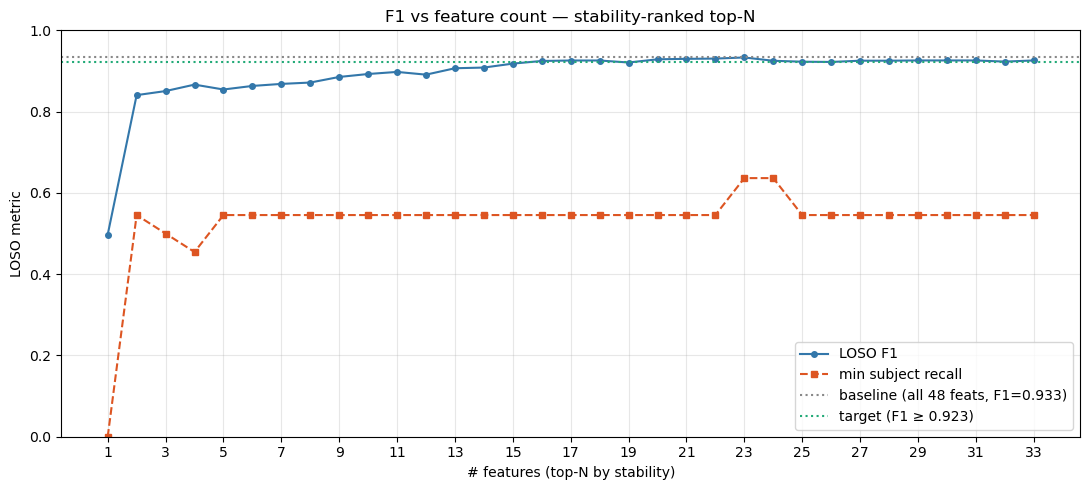


Smallest N meeting target (F1 ≥ 0.923, no subj < 0.5): N = 16, F1 = 0.925
Peak F1 along the curve:               N = 23, F1 = 0.933


In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(f1_vs_n_df['n_features'], f1_vs_n_df['mean_f1'],
        marker='o', markersize=4, label='LOSO F1', color='#37a')
ax.plot(f1_vs_n_df['n_features'], f1_vs_n_df['min_subject_recall'],
        marker='s', markersize=4, linestyle='--', label='min subject recall', color='#d52')
ax.axhline(BASELINE_F1, color='#888', linestyle=':', label=f'baseline (all {len(FEATURE_COLS)} feats, F1={BASELINE_F1:.3f})')
ax.axhline(TARGET_F1, color='#2a7', linestyle=':', label=f'target (F1 ≥ {TARGET_F1:.3f})')
ax.set_xlabel('# features (top-N by stability)')
ax.set_ylabel('LOSO metric')
ax.set_ylim(0, 1)
ax.set_xticks(n_options[::2])  # every other tick to avoid crowding
ax.set_title('F1 vs feature count — stability-ranked top-N')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'f1_vs_n_features.png', dpi=120)
plt.show()

# Smallest N that meets the target
passing = f1_vs_n_df[(f1_vs_n_df['mean_f1'] >= TARGET_F1) &
                    (f1_vs_n_df['n_below_0_5'] == 0)]
if len(passing):
    smallest = passing.iloc[0]
    print(f'\nSmallest N meeting target (F1 ≥ {TARGET_F1:.3f}, no subj < 0.5): '
          f'N = {int(smallest["n_features"])}, F1 = {smallest["mean_f1"]:.3f}')
    # Also show the peak
    peak = f1_vs_n_df.loc[f1_vs_n_df['mean_f1'].idxmax()]
    print(f'Peak F1 along the curve:               '
          f'N = {int(peak["n_features"])}, F1 = {peak["mean_f1"]:.3f}')
else:
    print(f'\nNo N meets target. Peak: N = {int(f1_vs_n_df.iloc[f1_vs_n_df["mean_f1"].idxmax()]["n_features"])}, '
          f'F1 = {f1_vs_n_df["mean_f1"].max():.3f}')

## §5 — SHAP across LOSO folds

Train HGB on each LOSO fold, compute SHAP values on the held-out subject, aggregate **mean |SHAP|** per feature across all test predictions. SHAP measures each feature's contribution to the model's decisions on truly held-out data — orthogonal to MI's univariate signal.

**Why both MI and SHAP?** MI ranks features by their *univariate* relationship to the label; SHAP ranks them by their *contribution within the fitted model*, which captures interactions. A feature can have low MI (small individual signal) but high SHAP (carries information that complements other features). The rebuild plan calls for comparing both rankings.

In [13]:
import shap

# Train HGB on each fold, compute SHAP on test subject; aggregate mean |SHAP| per feature
X_pruned = df_raw[PRUNED_FEATURES].fillna(0).values
shap_per_subject = {}
shap_abs_sum = pd.Series(0.0, index=PRUNED_FEATURES)
n_test_total = 0

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X_pruned, y_full, groups), 1):
    held_out = groups[test_idx[0]]
    t0 = time.time()
    clf = ev.hgb_factory()()
    clf.fit(X_pruned[train_idx], y_full[train_idx])
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(X_pruned[test_idx])
    # Binary classifier: shap_values may be a 3D array (n_test, n_features, n_classes) or 2D
    if isinstance(sv, list):
        sv = sv[1]  # positive class
    elif sv.ndim == 3:
        sv = sv[:, :, 1]
    abs_per_feat = np.abs(sv).mean(axis=0)  # mean over test windows
    shap_per_subject[held_out] = pd.Series(abs_per_feat, index=PRUNED_FEATURES)
    shap_abs_sum += pd.Series(abs_per_feat, index=PRUNED_FEATURES) * len(test_idx)
    n_test_total += len(test_idx)
    print(f'  fold {fold_idx:>2d}/14 ({held_out}): n_test={len(test_idx)}, {time.time()-t0:.1f}s')

shap_mean_abs = (shap_abs_sum / n_test_total).sort_values(ascending=False)
shap_df = pd.DataFrame({'feature': shap_mean_abs.index, 'mean_abs_shap': shap_mean_abs.values})
shap_df.to_csv(REPORTS_DIR / 'shap_ranking.csv', index=False)
print(f'\nTop-20 features by mean |SHAP| across all test windows:')
shap_df.head(20).round(4)

  fold  1/14 (S10): n_test=51, 0.7s
  fold  2/14 (S11): n_test=51, 0.8s
  fold  3/14 (S13): n_test=51, 1.0s
  fold  4/14 (S15): n_test=49, 1.4s
  fold  5/14 (S16): n_test=48, 0.8s
  fold  6/14 (S17): n_test=49, 1.9s
  fold  7/14 (S2): n_test=48, 0.7s
  fold  8/14 (S3): n_test=49, 0.6s
  fold  9/14 (S4): n_test=49, 1.4s
  fold 10/14 (S5): n_test=50, 0.8s
  fold 11/14 (S6): n_test=50, 1.0s
  fold 12/14 (S7): n_test=47, 1.4s
  fold 13/14 (S8): n_test=48, 0.8s
  fold 14/14 (S9): n_test=51, 0.6s

Top-20 features by mean |SHAP| across all test windows:


,feature,mean_abs_shap
0,scr_recovery_time_mean,3.6179
1,hrv_median_rr,1.3526
2,scr_peak_count,1.0297
3,scl_range,1.0186
4,hrv_pnn50,0.8738
5,scl_max,0.8541
6,temp_slope,0.7090
7,temp_max,0.7035
8,hrv_sdsd,0.5256
9,acc_jerk_mag_mean,0.4894


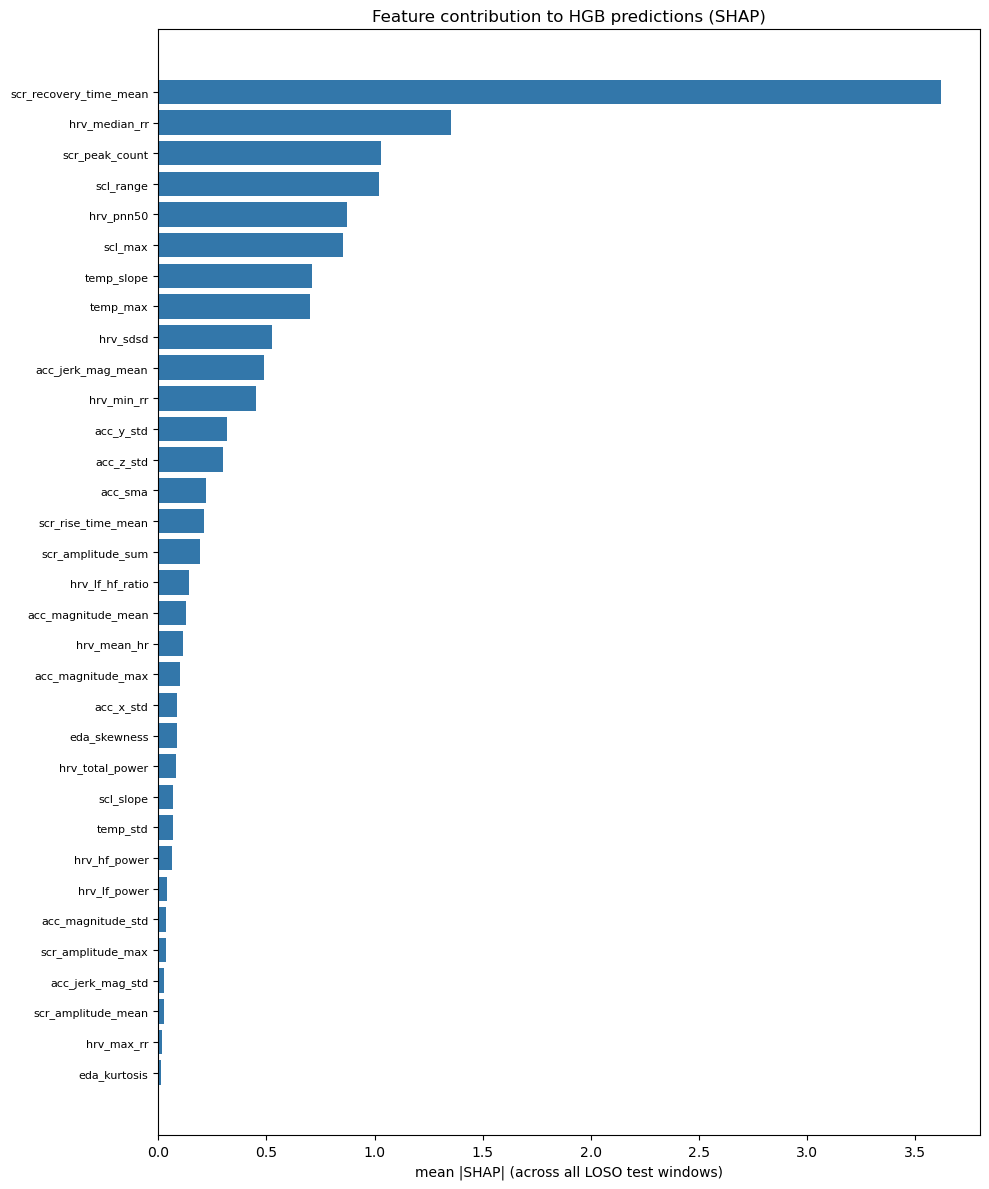

In [14]:
fig, ax = plt.subplots(figsize=(10, 12))
y_pos = np.arange(len(shap_df))
ax.barh(y_pos, shap_df['mean_abs_shap'], color='#37a')
ax.set_yticks(y_pos); ax.set_yticklabels(shap_df['feature'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('mean |SHAP| (across all LOSO test windows)')
ax.set_title('Feature contribution to HGB predictions (SHAP)')
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'shap_ranking.png', dpi=120)
plt.show()

## §6 — Stability vs SHAP comparison

How much do the two rankings agree? Strong agreement = both methods point to the same features = pick is robust. Weak agreement = methods disagree, and we have to choose which to trust (or take their union).

In [15]:
compare = stability_df[['feature', 'stability_score', 'mean_mi']].merge(
    shap_df, on='feature', how='outer'
).sort_values('mean_abs_shap', ascending=False)
compare['rank_stability'] = compare['stability_score'].rank(ascending=False, method='min').astype(int)
compare['rank_shap']      = compare['mean_abs_shap'].rank(ascending=False, method='min').astype(int)
compare['rank_diff']      = compare['rank_shap'] - compare['rank_stability']

compare.to_csv(REPORTS_DIR / 'ranking_comparison.csv', index=False)
print('Top-20 by SHAP, with stability rank for comparison:')
compare[['feature','rank_shap','rank_stability','rank_diff','stability_score','mean_abs_shap']].head(20).round(3)

Top-20 by SHAP, with stability rank for comparison:


,feature,rank_shap,rank_stability,rank_diff,stability_score,mean_abs_shap
28,scr_recovery_time_mean,1,1,0,1.000,3.618
16,hrv_median_rr,2,1,1,1.000,1.353
27,scr_peak_count,3,1,2,1.000,1.030
22,scl_range,4,13,-9,0.714,1.019
18,hrv_pnn50,5,1,4,1.000,0.874
21,scl_max,6,1,5,1.000,0.854
31,temp_slope,7,19,-12,0.071,0.709
30,temp_max,8,16,-8,0.357,0.703
19,hrv_sdsd,9,1,8,1.000,0.526
0,acc_jerk_mag_mean,10,16,-6,0.357,0.489


In [16]:
# Top-K overlap between the two rankings
for k in [10, 15, 20, 25]:
    top_stab = set(stability_df.head(k)['feature'])
    top_shap = set(shap_df.head(k)['feature'])
    overlap = top_stab & top_shap
    print(f'Top-{k:>2d} overlap: {len(overlap)}/{k} features ({100*len(overlap)/k:.0f}%)')
    if k == 15:
        only_stab = sorted(top_stab - top_shap)
        only_shap = sorted(top_shap - top_stab)
        print(f'  Only in stability top-15: {only_stab}')
        print(f'  Only in SHAP top-15:      {only_shap}')

Top-10 overlap: 6/10 features (60%)
Top-15 overlap: 9/15 features (60%)
  Only in stability top-15: ['acc_jerk_mag_std', 'acc_magnitude_std', 'hrv_max_rr', 'scr_amplitude_max', 'scr_amplitude_mean', 'scr_amplitude_sum']
  Only in SHAP top-15:      ['acc_jerk_mag_mean', 'acc_sma', 'acc_y_std', 'acc_z_std', 'temp_max', 'temp_slope']
Top-20 overlap: 14/20 features (70%)
Top-25 overlap: 20/25 features (80%)


## §7 — Final pick: stability vs SHAP vs combined-rank

The Phase 5 spec calls for picking by F1 + parsimony. We have **three** ranked lists now:

1. **Stability** — top-N features by fraction of LOSO folds where they appear in top-15 by MI.
2. **SHAP** — top-N features by mean |SHAP| across all LOSO test windows.
3. **Combined-rank** — `avg(rank_stability, rank_shap)`. Features that perform well in *both* rankings rise to the top; features good in only one drop. This is the "consensus" pick that the previous run was missing.

For each ranking, run F1-vs-N at every N from 1 to 33. The final pick is the smallest N within 0.005 of that ranking's peak F1, with no zero-recall subjects. Among the three plateau-elbow candidates, prefer (1) smallest N, (2) highest F1, (3) lowest deployment-risk features.

Combined-rank top-20 (avg of stability and SHAP ranks):
  feature                         stab_rank  shap_rank   combined  stab_score   |SHAP|
  scr_recovery_time_mean                  1          1        1.0       1.000    3.618
  hrv_median_rr                           1          2        1.5       1.000    1.353
  scr_peak_count                          1          3        2.0       1.000    1.030
  hrv_pnn50                               1          5        3.0       1.000    0.874
  scl_max                                 1          6        3.5       1.000    0.854
  hrv_sdsd                                1          9        5.0       1.000    0.526
  scl_range                              13          4        8.5       0.714    1.019
  scr_amplitude_sum                       1         16        8.5       1.000    0.195
  temp_max                               16          8       12.0       0.357    0.703
  hrv_min_rr                             15         11       13.0       0.

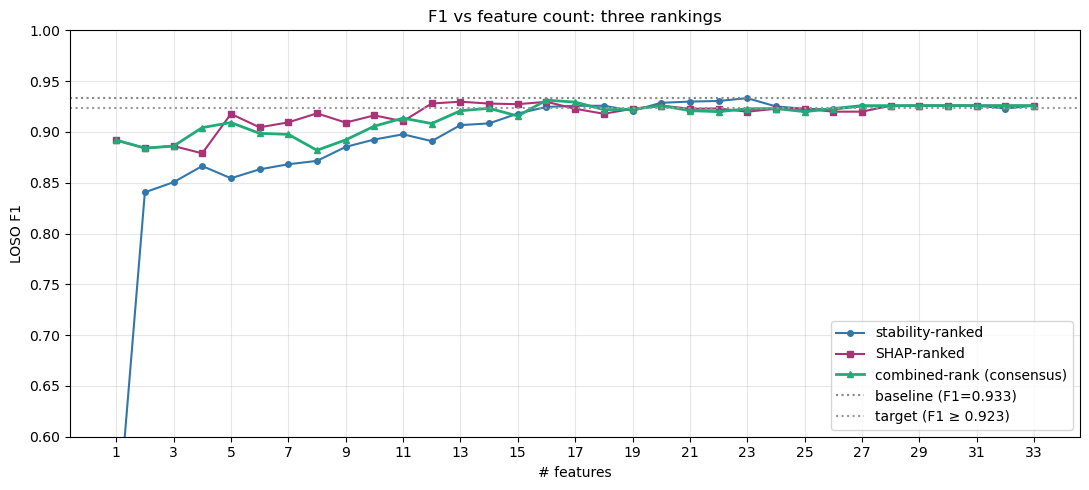

In [20]:
# Compute combined rank (avg of stability rank and SHAP rank). Lower = better
# in both rankings. Features in either ranking but not the other are penalized.
combined = compare.copy()
combined['combined_score'] = (combined['rank_stability'] + combined['rank_shap']) / 2.0
combined = combined.sort_values('combined_score').reset_index(drop=True)
combined_ranked = combined['feature'].tolist()

print('Combined-rank top-20 (avg of stability and SHAP ranks):')
print(f'  {"feature":<30s} {"stab_rank":>10s} {"shap_rank":>10s} {"combined":>10s} {"stab_score":>11s} {"|SHAP|":>8s}')
for f in combined_ranked[:20]:
    row = combined[combined['feature'] == f].iloc[0]
    print(f'  {f:<30s} {int(row.rank_stability):>10d} {int(row.rank_shap):>10d} '
          f'{row.combined_score:>10.1f} {row.stability_score:>11.3f} {row.mean_abs_shap:>8.3f}')

# F1-vs-N sweep for SHAP ranking (same as before)
shap_ranked = shap_df['feature'].tolist()
print('\nSHAP-ranked F1-vs-N sweep:')
f1_vs_n_shap = []
for n in n_options:
    cols_n = shap_ranked[:n]
    t0 = time.time()
    r = ev.loso_evaluate(df_raw, cols_n, model_factory=ev.hgb_factory())
    f1_vs_n_shap.append({
        'n_features': n,
        'mean_f1': r['mean_f1'], 'std_f1': r['std_f1'],
        'mean_recall': r['mean_recall'],
        'min_subject_recall': r['min_subject_recall'],
        'n_below_0_5': r['n_subjects_recall_below_0_5'],
        'elapsed_sec': round(time.time()-t0, 1),
    })
    print(f'  SHAP n={n:>2d}: F1={r["mean_f1"]:.3f}  '
          f'min_subj={r["min_subject_recall"]:.3f}  '
          f'#below_0.5={r["n_subjects_recall_below_0_5"]}/14  '
          f'({f1_vs_n_shap[-1]["elapsed_sec"]}s)')

# F1-vs-N sweep for combined-rank
print('\nCombined-rank F1-vs-N sweep:')
f1_vs_n_combined = []
for n in n_options:
    cols_n = combined_ranked[:n]
    t0 = time.time()
    r = ev.loso_evaluate(df_raw, cols_n, model_factory=ev.hgb_factory())
    f1_vs_n_combined.append({
        'n_features': n,
        'mean_f1': r['mean_f1'], 'std_f1': r['std_f1'],
        'mean_recall': r['mean_recall'],
        'min_subject_recall': r['min_subject_recall'],
        'n_below_0_5': r['n_subjects_recall_below_0_5'],
        'elapsed_sec': round(time.time()-t0, 1),
    })
    print(f'  combined n={n:>2d}: F1={r["mean_f1"]:.3f}  '
          f'min_subj={r["min_subject_recall"]:.3f}  '
          f'#below_0.5={r["n_subjects_recall_below_0_5"]}/14  '
          f'({f1_vs_n_combined[-1]["elapsed_sec"]}s)')

f1_vs_n_shap_df = pd.DataFrame(f1_vs_n_shap)
f1_vs_n_combined_df = pd.DataFrame(f1_vs_n_combined)
f1_vs_n_shap_df.to_csv(REPORTS_DIR / 'f1_vs_n_features_shap.csv', index=False)
f1_vs_n_combined_df.to_csv(REPORTS_DIR / 'f1_vs_n_features_combined.csv', index=False)

# Combined plot — three curves, no error bars
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(f1_vs_n_df['n_features'], f1_vs_n_df['mean_f1'],
        marker='o', markersize=4, label='stability-ranked', color='#37a')
ax.plot(f1_vs_n_shap_df['n_features'], f1_vs_n_shap_df['mean_f1'],
        marker='s', markersize=4, label='SHAP-ranked', color='#a37')
ax.plot(f1_vs_n_combined_df['n_features'], f1_vs_n_combined_df['mean_f1'],
        marker='^', markersize=5, label='combined-rank (consensus)', color='#2a7', linewidth=2.0)
ax.axhline(BASELINE_F1, color='#888', linestyle=':', label=f'baseline (F1={BASELINE_F1:.3f})')
ax.axhline(TARGET_F1, color='#999', linestyle=':', label=f'target (F1 ≥ {TARGET_F1:.3f})')
ax.set_xlabel('# features')
ax.set_ylabel('LOSO F1')
ax.set_xticks(n_options[::2])
ax.set_ylim(min(0.6, TARGET_F1-0.05), 1.0)
ax.set_title('F1 vs feature count: three rankings')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'f1_vs_n_combined.png', dpi=120)
plt.show()

In [21]:
# Compare the three rankings (stability, SHAP, combined-rank) and surface
# multiple decision points from the full N=1..|pruned| sweep, then pick.
PLATEAU_TOL = 0.005  # F1 within 0.005 of peak counts as "tied with peak"

def summarize_curve(curve_df, ranking_label, ranked_list):
    valid = curve_df[curve_df['n_below_0_5'] == 0]
    peak = curve_df.loc[curve_df['mean_f1'].idxmax()]
    peak_n = int(peak['n_features']); peak_f1 = peak['mean_f1']
    plateau = curve_df[(curve_df['mean_f1'] >= peak_f1 - PLATEAU_TOL) &
                       (curve_df['n_below_0_5'] == 0)]
    plateau_n = int(plateau.iloc[0]['n_features']) if len(plateau) else None
    passing = curve_df[(curve_df['mean_f1'] >= TARGET_F1) &
                       (curve_df['n_below_0_5'] == 0)]
    target_n = int(passing.iloc[0]['n_features']) if len(passing) else None
    print(f'  {ranking_label}:')
    if target_n:
        print(f'    smallest N meeting F1≥{TARGET_F1:.3f} & no zero-recall: '
              f'N={target_n}, F1={curve_df.iloc[target_n-1]["mean_f1"]:.3f}')
    else:
        print(f'    no N meets target')
    if plateau_n:
        print(f'    smallest N within {PLATEAU_TOL} of peak (plateau elbow): '
              f'N={plateau_n}, F1={curve_df.iloc[plateau_n-1]["mean_f1"]:.3f}')
    print(f'    peak F1 along curve: N={peak_n}, F1={peak_f1:.3f}')
    return {'ranking': ranking_label, 'target_n': target_n,
            'plateau_n': plateau_n, 'peak_n': peak_n, 'peak_f1': peak_f1,
            'curve_df': curve_df, 'ranked_list': ranked_list}

print(f'Full N=1..{len(PRUNED_FEATURES)} sweep summary:\n')
stab_summary     = summarize_curve(f1_vs_n_df,         'stability', ranked); print()
shap_summary     = summarize_curve(f1_vs_n_shap_df,    'SHAP',      shap_ranked); print()
combined_summary = summarize_curve(f1_vs_n_combined_df,'combined',  combined_ranked); print()

# Plateau-elbow candidates from each ranking
candidates = []
for s in [stab_summary, shap_summary, combined_summary]:
    if s['plateau_n']:
        n = s['plateau_n']
        row = s['curve_df'].iloc[n-1]
        candidates.append({
            'ranking': s['ranking'],
            'n_features': n,
            'features': s['ranked_list'][:n],
            'mean_f1': row['mean_f1'],
            'min_subject_recall': row['min_subject_recall'],
        })

if candidates:
    print(f'Plateau-elbow candidates (smallest N within {PLATEAU_TOL} of peak F1, no zero-recall):')
    for c in candidates:
        print(f"  {c['ranking']:>10s}: N={c['n_features']:>2d}, F1={c['mean_f1']:.3f}, "
              f"min_subj={c['min_subject_recall']:.3f}")

    # Decision rule: prefer combined-rank when its plateau N ties with the smallest
    # candidate (consensus is more defensible). Otherwise pick smallest N, breaking
    # ties by F1 then by min_subj_recall.
    smallest_n = min(c['n_features'] for c in candidates)
    tied = [c for c in candidates if c['n_features'] == smallest_n]
    if any(c['ranking'] == 'combined' for c in tied):
        chosen = next(c for c in tied if c['ranking'] == 'combined')
    else:
        chosen = max(tied, key=lambda c: (c['mean_f1'], c['min_subject_recall']))

    print(f"\nChosen: {chosen['ranking']}-ranked top-{chosen['n_features']}  "
          f"(F1={chosen['mean_f1']:.3f}, min_subj_recall={chosen['min_subject_recall']:.3f})")
    print('\nSelected features:')
    for f in chosen['features']:
        # Annotate each feature with its scores
        row = combined[combined['feature'] == f].iloc[0]
        print(f'  - {f:<30s} stab={row.stability_score:.3f}  |SHAP|={row.mean_abs_shap:.3f}  '
              f'(stab_rank={int(row.rank_stability):>2d}, shap_rank={int(row.rank_shap):>2d})')
    pd.Series(chosen['features']).to_csv(REPORTS_DIR / 'selected_features.csv', index=False, header=['feature'])
else:
    print('No candidate. Falling back to full pruned set.')
    chosen = {'ranking': 'baseline', 'n_features': len(PRUNED_FEATURES),
              'features': PRUNED_FEATURES,
              'mean_f1': post_prune['mean_f1'],
              'min_subject_recall': post_prune['min_subject_recall']}

# Per-subject recall on the chosen set
print(f'\nPer-subject recall on chosen {chosen["n_features"]}-feature set:')
chosen_eval = ev.loso_evaluate(df_raw, chosen['features'], model_factory=ev.hgb_factory())
psr_chosen = pd.Series(chosen_eval['per_subject_recall']).sort_index()
for sid, rec in psr_chosen.items():
    flag = ' ←' if rec < 0.7 else ''
    print(f'  {sid}: {rec:.3f}{flag}')

Full N=1..33 sweep summary:

  stability:
    smallest N meeting F1≥0.923 & no zero-recall: N=16, F1=0.925
    smallest N within 0.005 of peak (plateau elbow): N=20, F1=0.929
    peak F1 along curve: N=23, F1=0.933

  SHAP:
    smallest N meeting F1≥0.923 & no zero-recall: N=12, F1=0.928
    smallest N within 0.005 of peak (plateau elbow): N=12, F1=0.928
    peak F1 along curve: N=13, F1=0.930

  combined:
    smallest N meeting F1≥0.923 & no zero-recall: N=14, F1=0.923
    smallest N within 0.005 of peak (plateau elbow): N=16, F1=0.931
    peak F1 along curve: N=16, F1=0.931

Plateau-elbow candidates (smallest N within 0.005 of peak F1, no zero-recall):
   stability: N=20, F1=0.929, min_subj=0.545
        SHAP: N=12, F1=0.928, min_subj=0.636
    combined: N=16, F1=0.931, min_subj=0.545

Chosen: SHAP-ranked top-12  (F1=0.928, min_subj_recall=0.636)

Selected features:
  - scr_recovery_time_mean         stab=1.000  |SHAP|=3.618  (stab_rank= 1, shap_rank= 1)
  - hrv_median_rr            

## §8 — Findings & decision

*Bullet points to look for in the cells above:*
- How many features were collinear (|r| > 0.95)? Which family dominated (HRV time? SCL? temp?)
- Which features survive both stability AND SHAP rankings?
- Is there a parsimony elbow — a feature count beyond which F1 plateaus?
- Did `hrv_lf_hf_ratio` survive the rankings, given its high std?
- How does the chosen subset compare to the V2 author's pruned-19 list?

Once we have a winner, that feature subset locks for Phase 6 (model selection).

In [19]:
print('Phase 5 artifacts saved:')
for f in sorted(REPORTS_DIR.iterdir()):
    print(f'  reports/05_feature_selection/{f.name}')

Phase 5 artifacts saved:
  reports/05_feature_selection/correlation_matrix.png
  reports/05_feature_selection/f1_vs_n_combined.png
  reports/05_feature_selection/f1_vs_n_features.csv
  reports/05_feature_selection/f1_vs_n_features.png
  reports/05_feature_selection/f1_vs_n_features_shap.csv
  reports/05_feature_selection/ranking_comparison.csv
  reports/05_feature_selection/selected_features.csv
  reports/05_feature_selection/shap_ranking.csv
  reports/05_feature_selection/shap_ranking.png
  reports/05_feature_selection/stability_ranking.csv
  reports/05_feature_selection/stability_ranking.png
